MHSA



Solving topologies using MHSA algorithm...

Topology: star
Total Communication Cost (MHSA): 653.12

Topology: line
Total Communication Cost (MHSA): 501.54

Topology: cross
Total Communication Cost (MHSA): 503.94

Topology: ring
Total Communication Cost (MHSA): 492.48

Topology: quad
Total Communication Cost (MHSA): 532.36

Topology: star-traingl
Total Communication Cost (MHSA): 622.0

Topology: line-triangl
Total Communication Cost (MHSA): 531.0

Topology: cross-triangl
Total Communication Cost (MHSA): 553.36


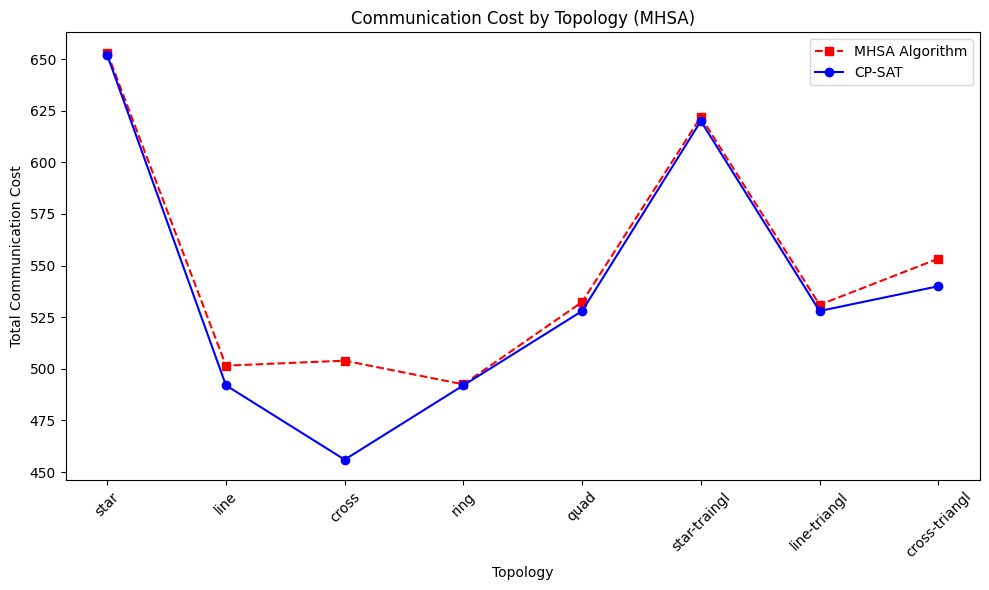

In [ ]:
"""
MHSA Topology Qubit Allocation Solver with Cost Plot

This program runs the MHSA algorithm for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install networkx matplotlib
"""

import random
import math
import matplotlib.pyplot as plt
import networkx as nx

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies)
coupled_pairs = [
    ((0, 1), 7),
    ((2, 3), 7),
    ((4, 5), 7),
    ((6, 7), 7),
    ((8, 9), 7),
    ((3, 4), 6),
    ((5, 6), 6),
    ((7, 8), 6),
    ((9, 10), 6),
    ((2, 4), 6),
    ((4, 6), 6),
    ((6, 8), 6),
    ((8, 10), 6),
    ((1, 2), 4),
    ((0, 2), 4),
    ((10, 11), 4),
    ((11, 12), 2),
    ((10, 12), 2),
    ((11, 13), 2),
    ((10, 13), 2),
    ((12, 13), 1)
]

# Define topology configurations
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}
def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost

def calculate_overhead(mapping, dist_matrix):
    overhead = 0
    for (q1, q2), count in coupled_pairs:
        v1 = mapping[q1]
        v2 = mapping[q2]
        d = dist_matrix[v1][v2]
        overhead += count * costs_from_distance[d]
    return overhead

def random_initial_mapping(capacities):
    allocation = {}
    available = {v: capacities[v] for v in range(NUM_NODES)}
    qubits = list(range(NUM_QUBITS))
    random.shuffle(qubits)
    for q in qubits:
        valid_nodes = [n for n in available if available[n] > 0]
        node = random.choice(valid_nodes)
        allocation[q] = node
        available[node] -= 1
    return allocation

def local_search(mapping, capacities, dist_matrix):
    current = mapping.copy()
    best_cost = calculate_overhead(current, dist_matrix)
    improved = True

    while improved:
        improved = False
        for q in range(NUM_QUBITS):
            for node in range(NUM_NODES):
                if current[q] == node:
                    continue
                count_in_node = sum(1 for v in current.values() if v == node)
                if count_in_node >= capacities[node]:
                    continue
                candidate = current.copy()
                candidate[q] = node
                candidate_cost = calculate_overhead(candidate, dist_matrix)
                if candidate_cost < best_cost:
                    current = candidate
                    best_cost = candidate_cost
                    improved = True
    return current, best_cost

def run_mhsa_for_topology(topo_config, alpha=0.9, nstage=50, neqlb=5, nstuck=5):
    capacities = topo_config["capacities"]
    dist_matrix = topo_config["distance_matrix"]

    best_mapping = None
    best_cost = float("inf")
    current_mapping = random_initial_mapping(capacities)
    current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)

    for stage in range(nstage):
        temp = 300
        stuck = 0
        while stuck < nstuck:
            for _ in range(neqlb):
                q = random.randint(0, NUM_QUBITS - 1)
                valid_nodes = [n for n in range(NUM_NODES) if sum(1 for v in current_mapping.values() if v == n) < capacities[n] or current_mapping[q] == n]
                if not valid_nodes:
                    continue
                node = random.choice(valid_nodes)
                neighbor = current_mapping.copy()
                neighbor[q] = node

                delta = calculate_overhead(neighbor, dist_matrix) - calculate_overhead(current_mapping, dist_matrix)
                if delta < 0 or random.random() < math.exp(-delta / temp):
                    current_mapping = neighbor
                    current_cost = calculate_overhead(current_mapping, dist_matrix)
                    if current_cost < best_cost:
                        best_mapping = current_mapping.copy()
                        best_cost = current_cost
                    stuck = 0
                else:
                    stuck += 1
            temp *= alpha
        current_mapping, current_cost = local_search(current_mapping, capacities, dist_matrix)
        if current_cost < best_cost:
            best_mapping = current_mapping.copy()
            best_cost = current_cost
    return best_mapping, best_cost

def main():
    topology_names = []
    mhsa_costs = []
    costs=[652,492,456,492,528,620,528,540]
    print("\n=================================================")
    print("Solving topologies using MHSA algorithm...")

    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        cost=0
        for i in range(100):
          solution, cost_val = run_mhsa_for_topology(topo)
          cost+=cost_val
        # solution2, cost_val2 = solve_topology(topo)
        cost/=100
        print(f"Total Communication Cost (MHSA): {cost}")
        # print(f"Total Communication Cost (CP-SAT): {cost_val2}")
        topology_names.append(name)
        mhsa_costs.append(cost)
        # costs.append(cost_val2)


    # Plot result
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, mhsa_costs, marker='s', linestyle='--', color='r', label='MHSA Algorithm')
    plt.plot(x, costs, marker='o', linestyle='-', color='b',label='CP-SAT')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology (MHSA)")
    plt.legend()
    plt.tight_layout()
    plt.show()





if __name__ == '__main__':
    main()


In [ ]:
!pip install ortools matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


410184



Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 652.0

Topology: line
Total Communication Cost: 492.0

Topology: cross
Total Communication Cost: 456.0

Topology: ring
Total Communication Cost: 492.0

Topology: quad
Total Communication Cost: 528.0

Topology: star-traingl
Total Communication Cost: 620.0

Topology: line-triangl
Total Communication Cost: 528.0

Topology: cross-triangl
Total Communication Cost: 540.0


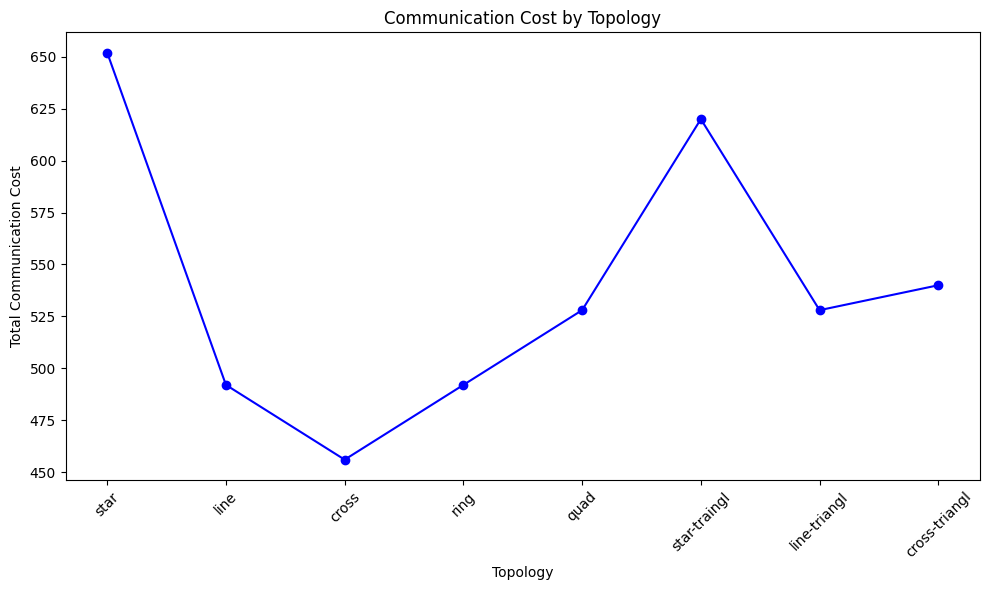

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((0, 1), 7),
((2, 3), 7),
((4, 5), 7),
((6, 7), 7),
((8, 9), 7),
((3, 4), 6),
((5, 6), 6),
((7, 8), 6),
((9, 10), 6),
((2, 4), 6),
((4, 6), 6),
((6, 8), 6),
((8, 10), 6),
((1, 2), 4),
((0, 2), 4),
((10, 11), 4),
((11, 12), 2),
((10, 12), 2),
((11, 13), 2),
((10, 13), 2),
((12, 13), 1)


]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

clip


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 174570.0

Topology: line
Total Communication Cost: 166796.0

Topology: cross
Total Communication Cost: 142850.0

Topology: ring
Total Communication Cost: 154018.0

Topology: quad
Total Communication Cost: 161532.0

Topology: star-traingl
Total Communication Cost: 169390.0

Topology: line-triangl
Total Communication Cost: 176178.0

Topology: cross-triangl
Total Communication Cost: 172928.0


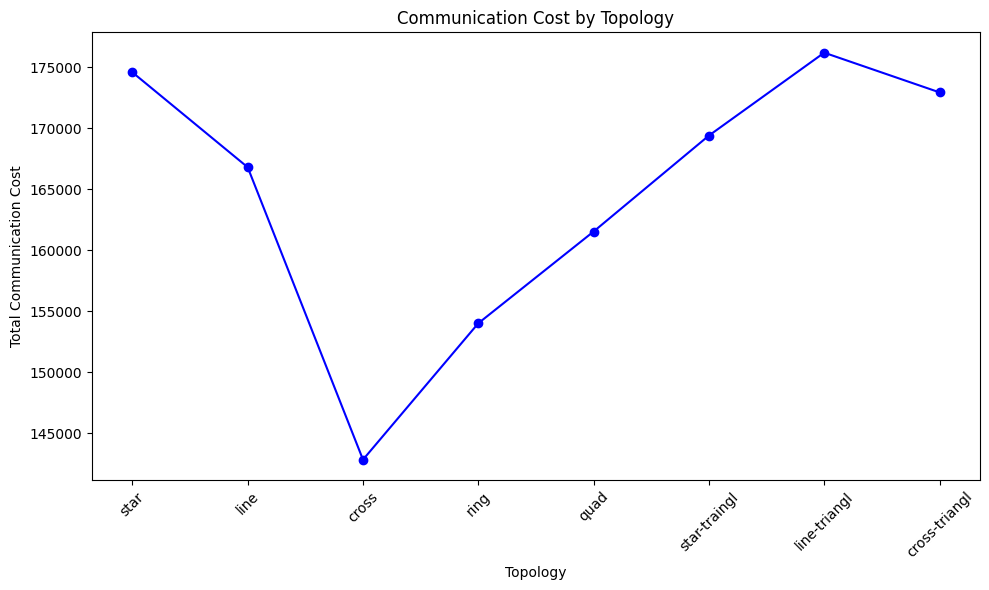

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((12, 13), 794),
((8, 11), 744),
((8, 9), 736),
((7, 11), 700),
((11, 12), 625),
((5, 12), 570),
((6, 11), 488),
((9, 10), 456),
((9, 11), 424),
((6, 12), 414),
((7, 10), 367),
((5, 13), 300),
((7, 12), 299),
((4, 8), 292),
((6, 9), 279),
((8, 10), 260),
((10, 11), 256),
((0, 13), 240),
((4, 9), 228),
((4, 11), 220),
((7, 9), 215),
((2, 11), 208),
((5, 10), 207),
((6, 8), 200),
((4, 5), 196),
((3, 11), 194),
((5, 8), 192),
((3, 4), 184),
((10, 13), 178),
((0, 10), 176),
((8, 13), 176),
((7, 8), 174),
((4, 13), 172),
((0, 9), 168),
((6, 10), 168),
((8, 12), 168),
((3, 10), 152),
((4, 10), 144),
((2, 3), 144),
((5, 9), 140),
((4, 7), 136),
((6, 7), 114),
((2, 13), 112),
((3, 8), 108),
((9, 13), 106),
((5, 11), 104),
((2, 12), 96),
((1, 9), 88),
((3, 9), 84),
((1, 11), 84),
((5, 6), 80),
((1, 12), 80),
((0, 4), 80),
((5, 7), 72),
((4, 6), 72),
((1, 5), 68),
((4, 12), 60),
((1, 3), 56),
((1, 10), 56),
((3, 13), 56),
((1, 13), 53),
((2, 8), 52),
((2, 5), 50),
((0, 3), 48),
((2, 9), 48),
((1, 2), 48),
((6, 13), 46),
((2, 10), 44),
((1, 6), 40),
((3, 12), 40),
((3, 6), 40),
((0, 5), 32),
((0, 2), 32),
((2, 4), 32),
((2, 6), 30),
((3, 5), 28),
((0, 6), 24),
((0, 12), 24),
((7, 13), 22),
((11, 13), 20),
((1, 7), 16),
((2, 7), 16),
((0, 7), 8),
((1, 8), 8),
((3, 7), 6),
((9, 12), 4),
((0, 8), 1)



]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

cm42a


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 6440.0

Topology: line
Total Communication Cost: 5076.0

Topology: cross
Total Communication Cost: 3988.0

Topology: ring
Total Communication Cost: 5500.0

Topology: quad
Total Communication Cost: 5492.0

Topology: star-traingl
Total Communication Cost: 5500.0

Topology: line-triangl
Total Communication Cost: 5156.0

Topology: cross-triangl
Total Communication Cost: 5596.0


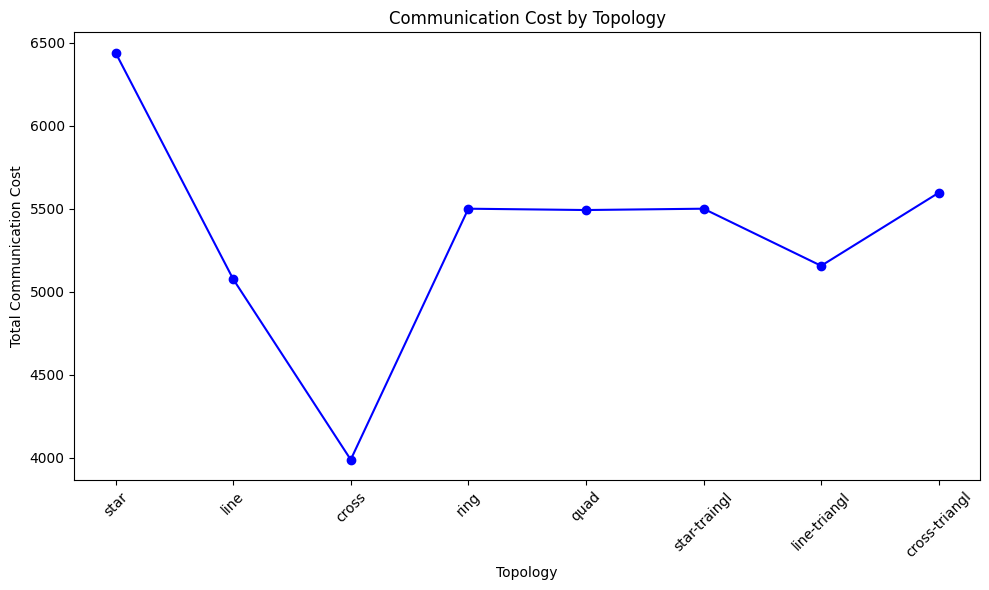

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((8, 11), 104),
((12, 13), 92),
((8, 9), 72),
((9, 11), 72),
((9, 10), 58),
((11, 12), 38),
((8, 13), 36),
((8, 12), 32),
((10, 13), 30),
((7, 11), 28),
((11, 13), 28),
((10, 11), 18),
((6, 10), 14),
((8, 10), 14),
((7, 9), 12),
((2, 10), 11),
((7, 10), 8),
((4, 10), 8),
((7, 8), 8),
((7, 12), 8),
((7, 13), 8),
((0, 10), 8),
((6, 11), 6),
((6, 9), 4),
((3, 9), 4),
((3, 10), 4),
((2, 9), 4),
((5, 9), 4),
((5, 10), 4),
((4, 9), 4),
((4, 13), 4),
((2, 13), 4),
((6, 13), 4),
((0, 9), 4),
((1, 9), 4),
((1, 10), 4),
((0, 13), 4),
((2, 11), 2)




]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

sao2


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 157344.0

Topology: line
Total Communication Cost: 134174.0

Topology: cross
Total Communication Cost: 126676.0

Topology: ring
Total Communication Cost: 137562.0

Topology: quad
Total Communication Cost: 138544.0

Topology: star-traingl
Total Communication Cost: 154260.0

Topology: line-triangl
Total Communication Cost: 153254.0

Topology: cross-triangl
Total Communication Cost: 148260.0


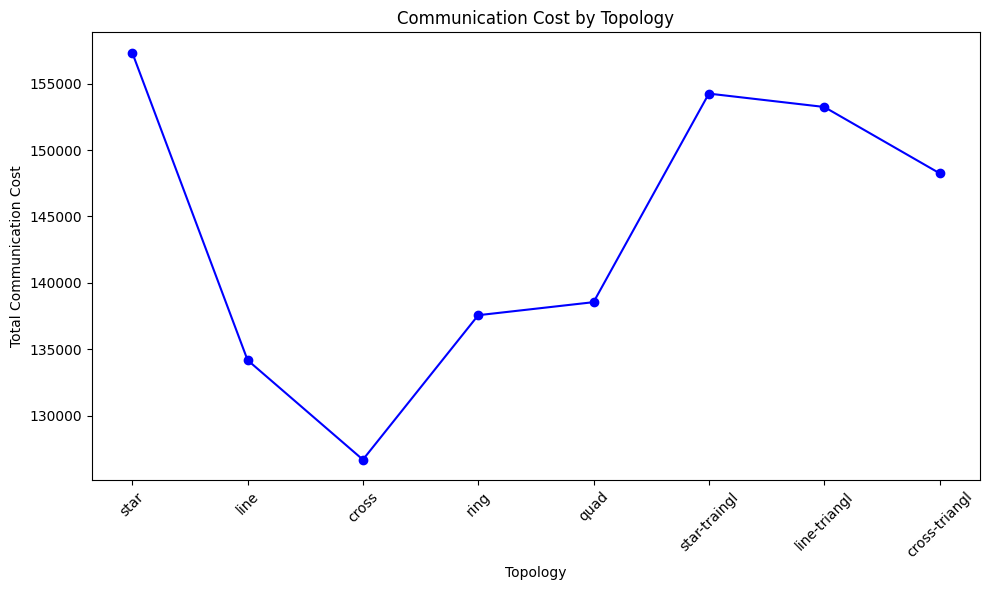

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 14   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((12, 13), 1220),
((4, 12), 1218),
((5, 11), 1008),
((11, 12), 918),
((8, 10), 848),
((8, 11), 824),
((4, 13), 806),
((6, 11), 776),
((10, 11), 688),
((5, 12), 672),
((0, 13), 612),
((6, 10), 612),
((8, 9), 596),
((7, 10), 592),
((7, 8), 444),
((9, 11), 440),
((9, 10), 424),
((8, 13), 392),
((8, 12), 380),
((7, 11), 376),
((0, 9), 288),
((1, 13), 248),
((0, 1), 192),
((6, 12), 192),
((6, 7), 160),
((0, 10), 144),
((10, 13), 140),
((10, 12), 128),
((2, 13), 120),
((9, 13), 112),
((0, 2), 112),
((1, 9), 100),
((3, 13), 100),
((11, 13), 98),
((0, 3), 96),
((9, 12), 96),
((0, 8), 58),
((6, 13), 56),
((0, 12), 52),
((6, 8), 48),
((1, 10), 44),
((5, 7), 36),
((3, 8), 36),
((0, 11), 32),
((5, 10), 24),
((3, 5), 24),
((5, 8), 24),
((3, 9), 24),
((1, 11), 24),
((2, 9), 24),
((1, 8), 24),
((1, 12), 16),
((2, 3), 16),
((7, 12), 16),
((5, 9), 12),
((2, 8), 12),
((1, 3), 8),
((2, 11), 8),
((5, 13), 8),
((7, 9), 8),
((6, 9), 8),
((2, 7), 8),
((1, 2), 8),
((2, 10), 8),
((0, 4), 6),
((1, 4), 5),
((2, 12), 4),
((2, 4), 4),
((3, 4), 4),
((4, 8), 3)

]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

misex1


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 20140.0

Topology: line
Total Communication Cost: 18432.0

Topology: cross
Total Communication Cost: 17088.0

Topology: ring
Total Communication Cost: 17940.0

Topology: quad
Total Communication Cost: 18840.0

Topology: star-traingl
Total Communication Cost: 20140.0

Topology: line-triangl
Total Communication Cost: 19176.0

Topology: cross-triangl
Total Communication Cost: 20016.0


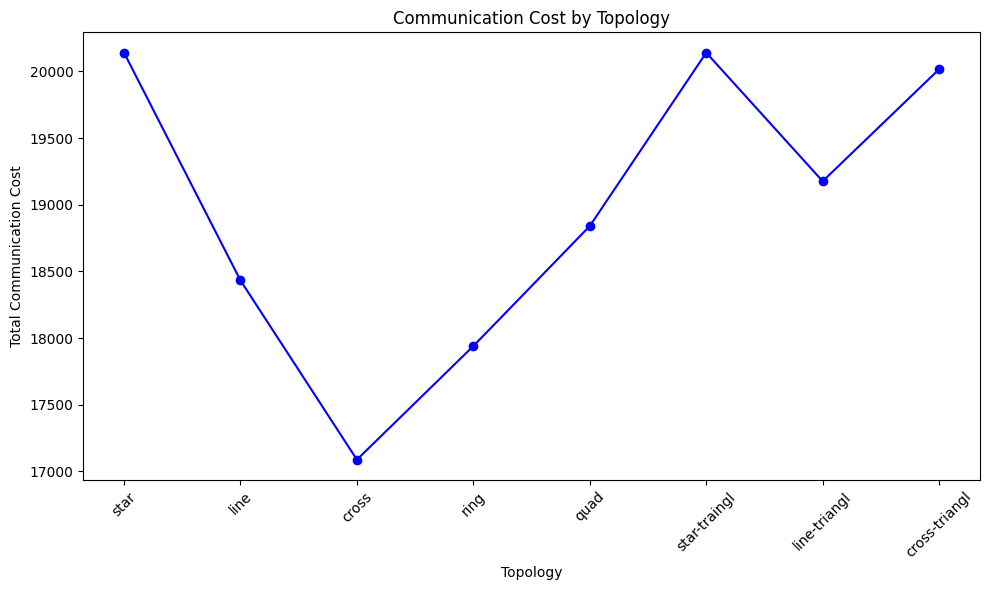

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((13, 14), 214),
((9, 10), 160),
((9, 12), 144),
((10, 11), 132),
((7, 12), 132),
((8, 11), 104),
((10, 12), 92),
((8, 10), 70),
((7, 8), 64),
((8, 12), 64),
((12, 14), 64),
((9, 11), 60),
((12, 13), 58),
((11, 12), 56),
((7, 13), 44),
((7, 14), 44),
((11, 14), 42),
((9, 13), 40),
((9, 14), 40),
((8, 9), 32),
((7, 9), 30),
((11, 13), 24),
((5, 12), 22),
((6, 11), 20),
((1, 11), 20),
((4, 10), 16),
((4, 11), 16),
((2, 11), 16),
((1, 10), 16),
((0, 10), 16),
((0, 11), 16),
((3, 11), 16),
((5, 11), 12),
((3, 10), 12),
((3, 9), 12),
((1, 12), 10),
((5, 14), 10),
((6, 10), 8),
((2, 10), 8),
((5, 10), 8),
((4, 9), 8),
((0, 9), 8),
((3, 7), 8),
((6, 8), 8),
((5, 6), 8),
((6, 12), 8),
((2, 12), 6),
((0, 12), 6),
((2, 14), 6),
((1, 14), 6),
((0, 14), 6),
((7, 11), 6),
((5, 9), 4),
((1, 9), 4),
((4, 12), 4),
((3, 12), 4),
((4, 13), 4),
((4, 14), 4),
((3, 13), 4),
((5, 8), 4),
((4, 8), 4),
((1, 8), 4),
((10, 13), 4),
((10, 14), 4),
((5, 13), 4)


]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

ham15


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 41900.0

Topology: line
Total Communication Cost: 38358.0

Topology: cross
Total Communication Cost: 30270.0

Topology: ring
Total Communication Cost: 37986.0

Topology: quad
Total Communication Cost: 38426.0

Topology: star-traingl
Total Communication Cost: 41782.0

Topology: line-triangl
Total Communication Cost: 40372.0

Topology: cross-triangl
Total Communication Cost: 40514.0


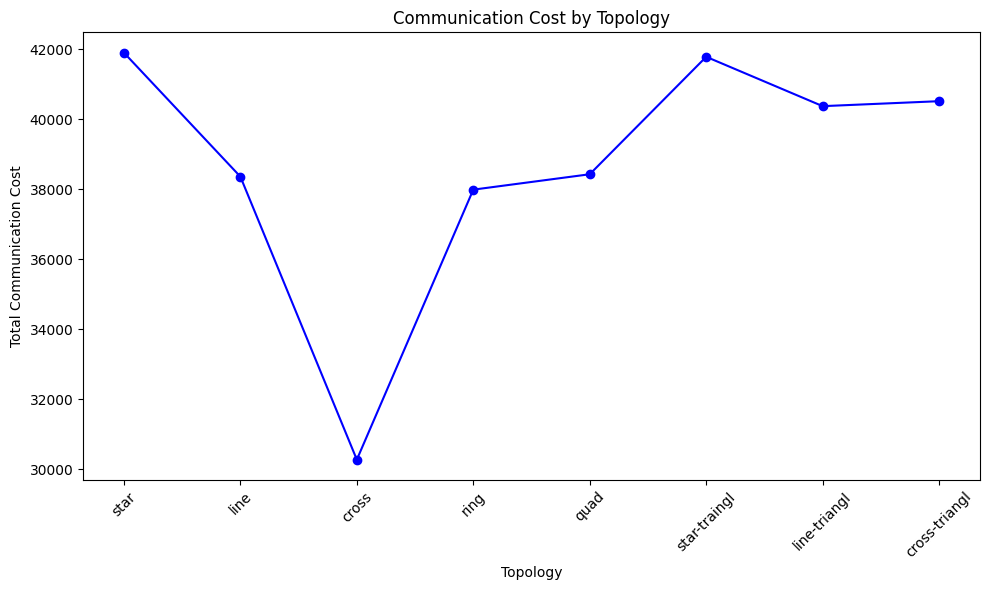

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((10, 13), 305),
((12, 13), 292),
((11, 13), 181),
((9, 13), 180),
((11, 12), 178),
((10, 11), 176),
((13, 14), 174),
((10, 12), 170),
((12, 14), 148),
((9, 12), 131),
((9, 10), 130),
((9, 11), 129),
((1, 14), 112),
((11, 14), 112),
((10, 14), 97),
((8, 13), 80),
((8, 12), 70),
((8, 10), 68),
((8, 11), 68),
((7, 12), 60),
((2, 9), 54),
((5, 11), 54),
((7, 8), 48),
((7, 11), 46),
((5, 9), 42),
((8, 9), 40),
((5, 10), 40),
((2, 14), 36),
((1, 13), 36),
((1, 11), 32),
((2, 12), 32),
((1, 12), 32),
((2, 13), 30),
((7, 10), 29),
((2, 5), 25),
((6, 7), 24),
((2, 10), 24),
((3, 14), 24),
((9, 14), 22),
((5, 12), 22),
((5, 14), 21),
((6, 11), 20),
((6, 10), 18),
((3, 10), 16),
((2, 8), 16),
((2, 11), 16),
((7, 13), 12),
((6, 12), 12),
((4, 11), 12),
((4, 10), 12),
((7, 14), 12),
((3, 13), 12),
((8, 14), 10),
((6, 9), 9),
((5, 8), 9),
((4, 6), 8),
((3, 4), 8),
((1, 10), 8),
((5, 6), 8),
((7, 9), 8),
((3, 12), 8),
((5, 13), 8),
((1, 8), 4),
((3, 9), 4),
((3, 5), 4),
((0, 10), 4),
((0, 14), 4),
((4, 14), 4),
((6, 14), 4),
((4, 8), 2),
((3, 7), 2),
((2, 6), 2),
((1, 5), 2),
((0, 4), 2),
((4, 7), 1),
((3, 6), 1),
((1, 4), 1),
((0, 3), 1)



]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

dc2


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 49684.0

Topology: line
Total Communication Cost: 47724.0

Topology: cross
Total Communication Cost: 42454.0

Topology: ring
Total Communication Cost: 45856.0

Topology: quad
Total Communication Cost: 46534.0

Topology: star-traingl
Total Communication Cost: 50220.0

Topology: line-triangl
Total Communication Cost: 48406.0

Topology: cross-triangl
Total Communication Cost: 51342.0


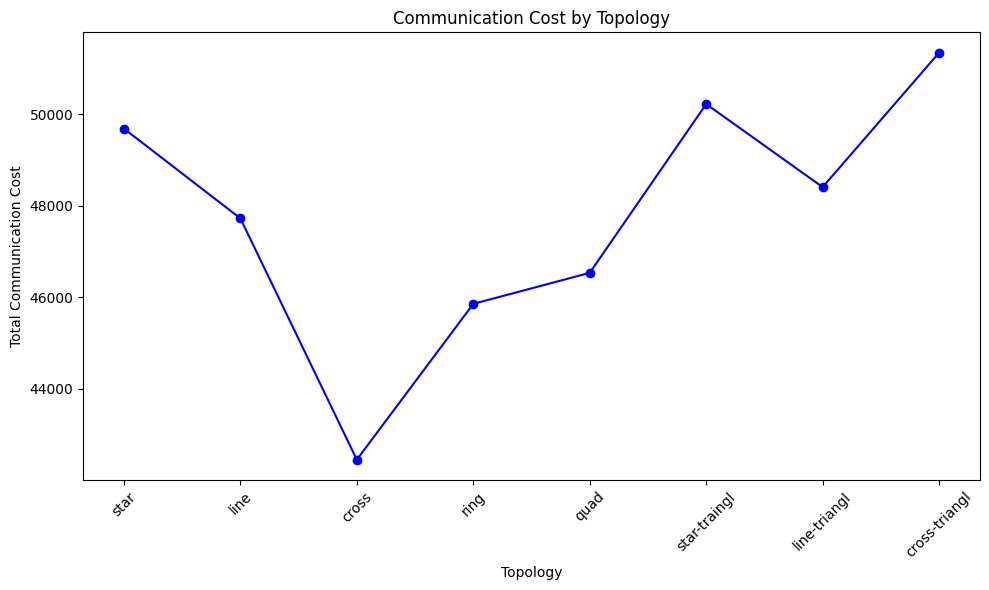

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]

# Global coupled pairs (common for all topologies).
# Format: ((q1, q2), count)
coupled_pairs = [
((13, 14), 222),
((7, 10), 172),
((7, 9), 156),
((6, 7), 132),
((9, 11), 130),
((7, 8), 122),
((7, 12), 120),
((6, 11), 112),
((9, 12), 112),
((7, 11), 112),
((9, 10), 102),
((6, 10), 100),
((5, 11), 100),
((5, 6), 96),
((9, 13), 84),
((8, 11), 82),
((6, 9), 76),
((4, 11), 74),
((10, 11), 72),
((10, 13), 72),
((5, 10), 72),
((5, 12), 72),
((7, 14), 72),
((2, 12), 72),
((4, 12), 70),
((8, 12), 66),
((8, 10), 66),
((8, 9), 64),
((12, 14), 62),
((12, 13), 57),
((11, 14), 57),
((11, 13), 56),
((10, 12), 52),
((3, 11), 52),
((4, 10), 52),
((6, 12), 52),
((3, 12), 52),
((8, 13), 50),
((11, 12), 46),
((2, 13), 44),
((7, 13), 44),
((9, 14), 40),
((4, 5), 40),
((5, 13), 36),
((3, 8), 32),
((4, 6), 32),
((3, 4), 32),
((2, 3), 32),
((3, 13), 28),
((3, 10), 28),
((5, 14), 24),
((5, 7), 24),
((4, 8), 24),
((2, 14), 24),
((4, 14), 22),
((4, 13), 18),
((1, 8), 16),
((5, 8), 16),
((5, 9), 16),
((2, 4), 16),
((1, 13), 12),
((10, 14), 12),
((2, 9), 12),
((4, 9), 12),
((3, 9), 12),
((8, 14), 12),
((2, 8), 12),
((2, 10), 8),
((1, 10), 8),
((6, 8), 8),
((3, 7), 8),
((3, 5), 8),
((3, 14), 8),
((1, 9), 4),
((1, 11), 4),
((2, 11), 4),
((4, 7), 4),
((1, 7), 4),
((0, 7), 1)




]

# Define topology configurations.
# For each topology, fill in:
#   "name": topology name,
#   "capacities": list of 5 integers (capacity per node),
#   "distance_matrix": a 5x5 matrix (list of lists) of distances (values 0 to 4).
topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}


def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs:
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main():
    topology_names = []
    costs = []

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

co14


Solving topologies and collecting total cost...

Topology: star
Total Communication Cost: 77832.0

Topology: line
Total Communication Cost: 66664.0

Topology: cross
Total Communication Cost: 71120.0

Topology: ring
Total Communication Cost: 68368.0

Topology: quad
Total Communication Cost: 69216.0

Topology: star-traingl
Total Communication Cost: 75136.0

Topology: line-triangl
Total Communication Cost: 67800.0

Topology: cross-triangl
Total Communication Cost: 66904.0


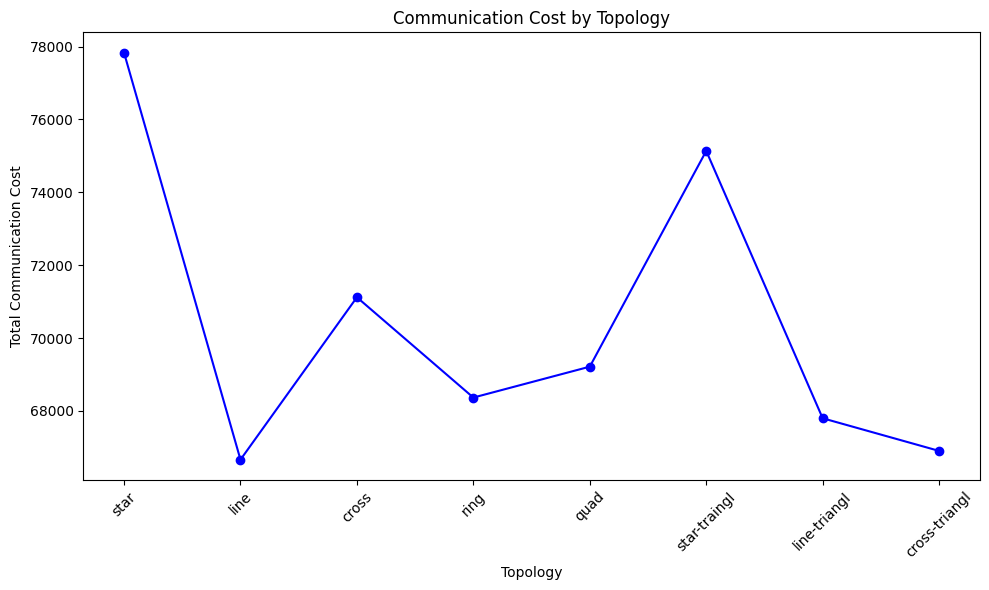

In [ ]:
"""
Topology Qubit Allocation Solver with Cost Plot

This program runs a CP-SAT solver for multiple topologies and then plots the final total
communication cost for each topology on a graph. The x-axis represents different topologies,
and the y-axis shows the computed cost. The data points are connected by a straight line.

Assumptions:
  - There are NUM_NODES = 5 nodes and NUM_QUBITS = 14 qubits.
  - For each topology, capacity constraints and a 5x5 distance matrix (with values between 0 and 4)
    are specified.
  - The coupled pairs definition is global and is the same for all topologies.
  - The cost mapping is specified using a list: distance 0, 1, 2, 3, 4 map to cost values.
         e.g., distance: 0 -> cost=0, 1 -> cost=12, 2 -> cost=22, 3 -> cost=32, 4 -> cost=42.

To run this file, please install:
    pip install ortools matplotlib
"""

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt
import re
from collections import Counter

# Global parameters
NUM_NODES = 5     # Fixed for all topologies.
NUM_QUBITS = 15   # Fixed for all topologies.

# Global cost mapping
# For example: distance mapping to cost: 0 -> 0, 1 -> 12, 2 -> 22, 3 -> 32, 4 -> 42.
costs_from_distance = [0, 12, 22, 32, 42]


topologies = {
    "star": {
        "name": "star",
        "capacities": [1, 4, 4, 4, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 2, 2],
            [1, 2, 2, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line": {
        "name": "line",
        "capacities": [4, 3, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 2, 3, 4],
            [1, 0, 1, 2, 3],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [4, 3, 2, 1, 0]
        ]
    },
    "cross": {
        "name": "cross",
        "capacities": [4, 3, 2, 4, 5],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 2],
            [3, 2, 1, 2, 0]
        ]
    },
    "ring": {
        "name": "ring",
        "capacities": [3, 3, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 2, 1],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 2],
            [2, 2, 1, 0, 1],
            [1, 2, 2, 1, 0]
        ]
    },
    "quad": {
        "name": "quad",
        "capacities": [4, 2, 3, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 2],
            [1, 0, 1, 2, 1],
            [2, 1, 0, 1, 2],
            [3, 2, 1, 0, 1],
            [2, 1, 2, 1, 0]
        ]
    },
    "star-traingl": {
        "name": "star-traingl",
        "capacities": [1, 4, 3, 3, 4],
        "distance_matrix": [
            [0, 1, 1, 1, 1],
            [1, 0, 2, 2, 2],
            [1, 2, 0, 1, 2],
            [1, 2, 1, 0, 2],
            [1, 2, 2, 2, 0]
        ]
    },
    "line-triangl": {
        "name": "line-triangl",
        "capacities": [4, 3, 2, 3, 3],
        "distance_matrix": [
            [0, 1, 2, 3, 3],
            [1, 0, 1, 2, 2],
            [2, 1, 0, 1, 1],
            [3, 2, 1, 0, 1],
            [3, 2, 1, 1, 0]
        ]
    },
    "cross-triangl": {
        "name": "cross-triangl",
        "capacities": [4, 2, 3, 2, 4],
        "distance_matrix": [
            [0, 1, 2, 2, 3],
            [1, 0, 1, 1, 2],
            [2, 1, 0, 1, 2],
            [2, 1, 1, 0, 1],
            [3, 2, 2, 1, 0]
        ]
    }
}
def extract_cnot_operations(qasm_file):
    """Extracts CNOT pairs and counts from a given QASM file."""
    with open(qasm_file, 'r') as file:
        qasm_content = file.read()

    cnot_pattern = r'cx q\[(\d+)\],q\[(\d+)\]'
    cnot_pairs = re.findall(cnot_pattern, qasm_content)

    # Normalize pairs
    normalized_pairs = [tuple(sorted((int(a), int(b)))) for a, b in cnot_pairs]

    # Count occurrences
    return (Counter(normalized_pairs))

def solve_topology(topo_config):
    """
    Solves the qubit allocation problem for the given topology configuration.
    Returns a tuple (solution, cost) where:
      - solution is a dict mapping qubit index -> assigned node,
      - cost is the total communication cost.
    """
    model = cp_model.CpModel()

    # Create indicator variables: b[(i, n)] == 1 if qubit i is assigned to node n.
    b = {}
    for i in range(NUM_QUBITS):
        for n in range(NUM_NODES):
            b[(i, n)] = model.NewBoolVar(f"b_{i}_{n}")

    # Each qubit must be assigned to exactly one node.
    for i in range(NUM_QUBITS):
        model.Add(sum(b[(i, n)] for n in range(NUM_NODES)) == 1)

    # Create qubit_node variable representing the node assigned to qubit i.
    qubit_node = []
    for i in range(NUM_QUBITS):
        q_node = model.NewIntVar(0, NUM_NODES - 1, f'qubit_{i}_node')
        model.Add(q_node == sum(n * b[(i, n)] for n in range(NUM_NODES)))
        qubit_node.append(q_node)

    # Enforce capacity constraints for each node.
    capacities = topo_config["capacities"]
    for n in range(NUM_NODES):
        model.Add(sum(b[(i, n)] for i in range(NUM_QUBITS)) <= capacities[n])

    total_cost_terms = []
    # Flatten distance matrix.
    distance_matrix = topo_config["distance_matrix"]
    distance_flat = [distance_matrix[i][j] for i in range(NUM_NODES) for j in range(NUM_NODES)]

    # Process each coupled pair.
    for (q1, q2), count in coupled_pairs.items():
        # Calculate the index into the flattened distance matrix:
        idx = model.NewIntVar(0, NUM_NODES * NUM_NODES - 1, f'index_{q1}_{q2}')
        model.Add(idx == qubit_node[q1] * NUM_NODES + qubit_node[q2])

        # Get the distance using an Element constraint.
        d = model.NewIntVar(0, 4, f'distance_{q1}_{q2}')
        model.AddElement(idx, distance_flat, d)

        # Map distance to cost.
        pair_cost_var = model.NewIntVar(0, max(costs_from_distance), f'pair_cost_{q1}_{q2}')
        model.AddElement(d, costs_from_distance, pair_cost_var)

        total_cost_terms.append(count * pair_cost_var)

    model.Minimize(sum(total_cost_terms))

    # Solve the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    status = solver.Solve(model)
    solution = {}
    total_cost = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for i in range(NUM_QUBITS):
            solution[i] = solver.Value(qubit_node[i])
        total_cost = solver.ObjectiveValue()
    else:
        print(f"No solution found for topology {topo_config['name']}")

    return solution, total_cost


def main(qasm_file):
    topology_names = []
    costs = []
    global coupled_pairs
    coupled_pairs = extract_cnot_operations(qasm_file)

    print("\n=================================================")
    print("Solving topologies and collecting total cost...")

    # Solve for each topology.
    for name, topo in topologies.items():
        print(f"\nTopology: {name}")
        solution, cost_val = solve_topology(topo)
        if solution is not None and cost_val is not None:
            print(f"Total Communication Cost: {cost_val}")
            topology_names.append(name)
            costs.append(cost_val)
        else:
            print(f"Could not solve topology {name}")

    # Plot result: x-axis = topology names, y-axis = total cost.
    plt.figure(figsize=(10, 6))
    x = list(range(len(topology_names)))
    plt.plot(x, costs, marker='o', linestyle='-', color='b')
    plt.xticks(x, topology_names, rotation=45)
    plt.xlabel("Topology")
    plt.ylabel("Total Communication Cost")
    plt.title("Communication Cost by Topology")
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    qasm_file ="/content/co14_215.qasm"
    main(qasm_file)